# EDA: Netflix Movies and TV Shows

## Датасет
Содержит информацию о фильмах и сериалах:
- тип контента (Movie / TV Show)
- название
- режиссеры и актеры
- страна производства
- дата добавления на платформу
- год выпуска
- рейтинг
- длительность
- жанры (listed_in)
- описание

Источник: https://www.kaggle.com/datasets/shivamb/netflix-shows

# A) ОБЗОР ДАННЫХ
## Импорт библиотек и загрузка данных

In [ ]:
import pandas as pd
import numpy as np
# визуализация
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv') # загрузка
df.head() # первые 5 строк

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.tail() # последние 5 строк

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [3]:
df.shape # размер: количество строк, столбцов

(8807, 12)

In [4]:
df.info() # названия колонок, типы данных, количество непустых значений

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [5]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [6]:
df.describe(include='object') # статистика по текстовым колонкам

C:\Users\kilom\AppData\Local\Temp\ipykernel_29852\3796705964.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object') # статистика по текстовым колонкам


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [7]:
df.isnull().sum() # количество пропущенных значений в каждой колонке

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df.duplicated().sum() # количество дубликатов

np.int64(0)

# B) ПРОПУСКИ И ОЧИСТКА
## 1. Повторная фиксация пропусков: контроль перед обработкой

In [9]:
missing_values = df.isnull().sum() # количество пропусков в каждом столбце
missing_values.sort_values(ascending=False) # по убыванию

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

## Способ 1: Удаление пропусков (dropna)

In [10]:
df_drop_example = df.dropna(subset=['country']) #удалим строки, где не указана страна
df_drop_example.shape

(7976, 12)

## Способ 2: Заполнение пропусков (fillna)
### Заполнение категориальных данных (mode)

In [ ]:
country_mode = df['country'].mode()[0] # мода стран
df['country'] = df['country'].fillna(country_mode) # заполнить пропуски
df['country'].isnull().sum() # проверка

np.int64(0)

### Заполнение других категориальных колонок

In [12]:
# заполняем director и cast значением Unknown
# если пропущено много данных то лучше использовать отдельную категорию
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

### Работа с датами
Дата добавления важна для анализа (например, временные тренды) поэтому строки без нее можно удалить, если их немного.

In [13]:
df['date_added'].isnull().sum() # проверим пропуски в date_added

np.int64(10)

In [14]:
df = df.dropna(subset=['date_added']) # удалим строки без даты если их немного

### Проверка после очистки

In [15]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          4
duration        3
listed_in       0
description     0
dtype: int64

## Обработка пропусков: вывод
- В датасете присутствовали значительные пропуски в категориальных колонках
- dropna использовалось ограниченно, т. к. приводит к потере данных
- Для категориальных признаков применено заполнение модой
- Для некоторых колонок присвоено особое значение Unknown
- Критически важные пропуски были удалены

В результате данные стали более полными, теперь они пригодны для анализа

# C) РАСШИРЕННАЯ СТАТИСТИКА

## 1. Преобразование длительности в число
Колонка duration содержит текст.
Для анализа мы извлечем число и переведем его в float

In [16]:
# новая колонка с длительностью в виде числа
df['duration_num'] = df['duration'].str.split(' ').str[0].astype(float)
df[['duration', 'duration_num']].head()

,duration,duration_num
0,90 min,90.0
1,2 Seasons,2.0
2,1 Season,1.0
3,1 Season,1.0
4,2 Seasons,2.0


## 2. Статистика
Считаем основные характеристики, чтобы оценить данные.

In [17]:
df['duration_num'].agg(['min', 'max', 'mean', 'median'])

min         1.000000
max       312.000000
mean       69.920173
median     88.000000
Name: duration_num, dtype: float64

In [18]:
df['duration_num'].mode() # мода

0    1.0
Name: duration_num, dtype: float64

In [19]:
df['duration_num'].quantile([0.05, 0.25, 0.5, 0.75, 0.95]) # процентили

0.05      1.0
0.25      2.0
0.50     88.0
0.75    106.0
0.95    139.0
Name: duration_num, dtype: float64

In [20]:
df['duration_num'].var() # дисперсия aka variance

np.float64(2580.335717199736)

In [21]:
df['duration_num'].skew() # асимметрия aka skewness

np.float64(-0.1922960404673704)

In [22]:
df['duration_num'].kurt() # эксцесс aka kurtosis

np.float64(-1.0788531980254177)

##  Расширенная статистика: вывод
- Длительность контента варьируется в широком диапазоне - большая(2580) дисперсия
- Среднее и медиана отличаются -> распределение асимметрично. отрицательная(-0.19) - левый хвост длиннее. на нетфликсе больше короткого контента.
- Основная масса значений сосредоточена в определенном диапазоне
- Присутствуют выбросы
- Данные не распределены нормально
- отрицательный(-1.07) эксцесс: у нетфликса нет одного жесткого стандарта длительности

# D) FEATURE ENGINEERING И ENCODING
##  Кодирование категориальных признаков - encoding
### One-Hot Encoding
Строковые категориальные признаки надо преобразовать в числовые.
One-Hot Encoding создает отдельную колонку для каждой категории, значения 0 или 1

In [23]:
# one-hot encoding для type
df_encoded = pd.get_dummies(df, columns=['type'], drop_first=True)
df_encoded.head()

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,type_TV Show
0,s1,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,False
1,s2,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,True
2,s3,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,True
3,s4,Jailbirds New Orleans,Unknown,Unknown,United States,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,True
4,s5,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,True


###  Label Encoding
Заменяет категории числами. 
!!Однако метод может создавать "ложный порядок"

In [24]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() # экземпляр кодировщика
# fit смотрит rating, находит все уникальные значения,
# присваивает каждому уникальное число
# transform заменяет текст на числа во всем столбце
df['rating_encoded'] = le.fit_transform(df['rating'])
df[['rating', 'rating_encoded']].head()

,rating,rating_encoded
0,PG-13,7
1,TV-MA,11
2,TV-MA,11
3,TV-MA,11
4,TV-MA,11


## Feature Engineering: создание новых признаков
### Год добавления контента

In [ ]:
# errors='coerce' не выдаст ошибку а сделает not a time
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year # извлекаем год из даты
df[['date_added', 'year_added']].head()


,date_added,year_added
0,2021-09-25,2021.0
1,2021-09-24,2021.0
2,2021-09-24,2021.0
3,2021-09-24,2021.0
4,2021-09-24,2021.0


## Количество актеров

In [26]:
df['cast_count'] = df['cast'].apply(lambda x: len(str(x).split(',')))
df[['cast', 'cast_count']].head()

,cast,cast_count
0,Unknown,1
1,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",19
2,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",9
3,Unknown,1
4,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",8


## Разделение длительности (фильмы vs сериалы)
В колонке duration: фильмы -> min, cериалы -> seasons

In [27]:
# бинарный признак: фильм(1) или сериал(0)
df['is_movie'] = df['duration'].str.contains('min').astype(int)
df[['duration', 'is_movie']].head()

,duration,is_movie
0,90 min,1
1,2 Seasons,0
2,1 Season,0
3,1 Season,0
4,2 Seasons,0


## Группировка редких стран
Если категорий слишком много то это усложняет анализ. Поэтому мы оставим популярные страны, а остальные объединим в Other

In [28]:
top_countries = df['country'].value_counts().head(10).index # топ 10 стран
# остальные объединяем
df['country_grouped'] = df['country'].apply(
    lambda x: x if x in top_countries else 'Other'
)
df['country_grouped'].value_counts()

country_grouped
United States     3642
Other             2656
India              972
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

## Feature Hashing
Используется когда очень много уникальных значений

In [ ]:
from sklearn.feature_extraction import FeatureHasher
# ограничение в 5 колонок + на вход подаются строки (жанр).
hasher = FeatureHasher(n_features=5, input_type='string')
hashed_features = hasher.transform(df['listed_in'].str.split(', ')) # каждое слово через запятую
hashed_df = pd.DataFrame(hashed_features.toarray()) # разряженная матрица
hashed_df.head()

,0,1,2,3,4
0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,-1.0,0.0
2,1.0,1.0,-1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,1.0
4,0.0,0.0,0.0,-1.0,0.0


## Проверка новых признаков

In [30]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,rating_encoded,year_added,cast_count,is_movie,country_grouped
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,7,2021.0,1,1,United States
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,11,2021.0,19,0,Other
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,11,2021.0,9,0,United States
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,11,2021.0,1,0,United States
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,11,2021.0,8,0,India


# E) ВИЗУАЛИЗАЦИЯ ДАННЫХ
## Распределение длительности: Histogram + KDE

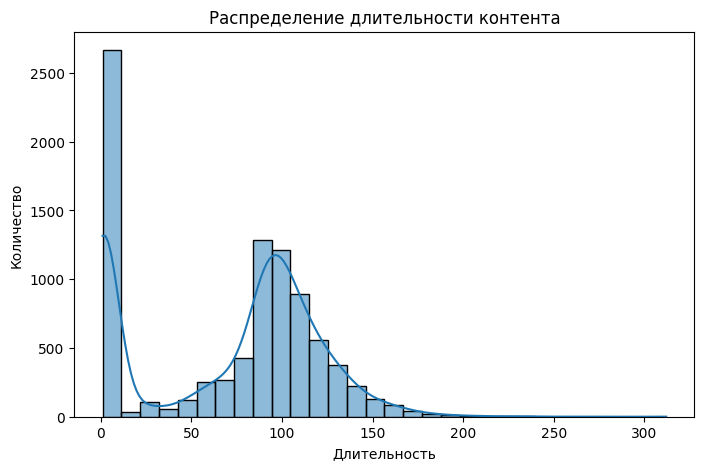

In [31]:
plt.figure(figsize=(8, 5)) # область 8 на 5
# график из duration num + 30 интервалов + плавная линия kde
sns.histplot(df['duration_num'], bins=30, kde=True)
plt.title('Распределение длительности контента')
plt.xlabel('Длительность')
plt.ylabel('Количество')
plt.show()

## Scatter plot
Показывает зависимость между двумя числовыми переменными.
С его помощью можно выявить тренды и закономерности

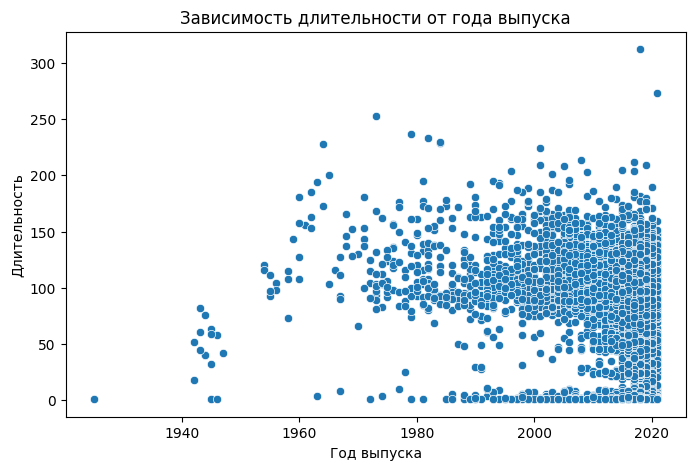

In [32]:
plt.figure(figsize=(8, 5))
# оси x и y + данные из df
sns.scatterplot(x='release_year', y='duration_num', data=df)
plt.title('Зависимость длительности от года выпуска')
plt.xlabel('Год выпуска')
plt.ylabel('Длительность')
plt.show()

## Boxplot
Показывает медиану, квартили, выбросы

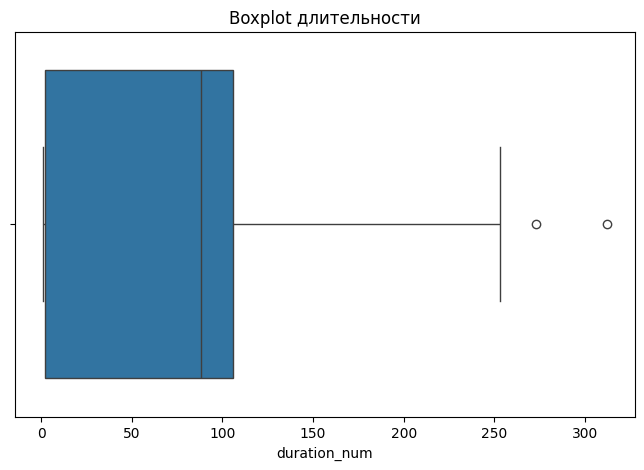

In [33]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['duration_num']) # ящик
plt.title('Boxplot длительности')
plt.show()

## Countplot
Показывает распределение категорий.

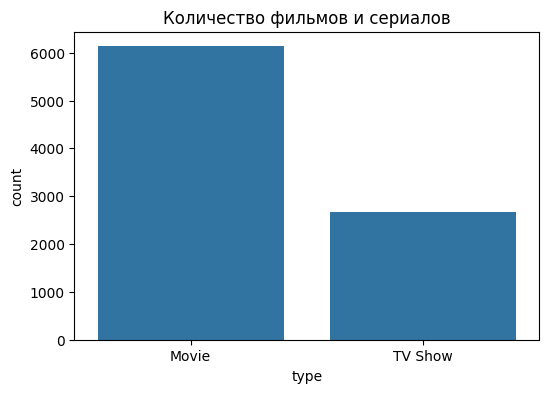

In [34]:
plt.figure(figsize=(6, 4))
sns.countplot(x='type', data=df)
plt.title('Количество фильмов и сериалов')
plt.show()

## Топ стран
Показывает, какие страны производят больше контента.

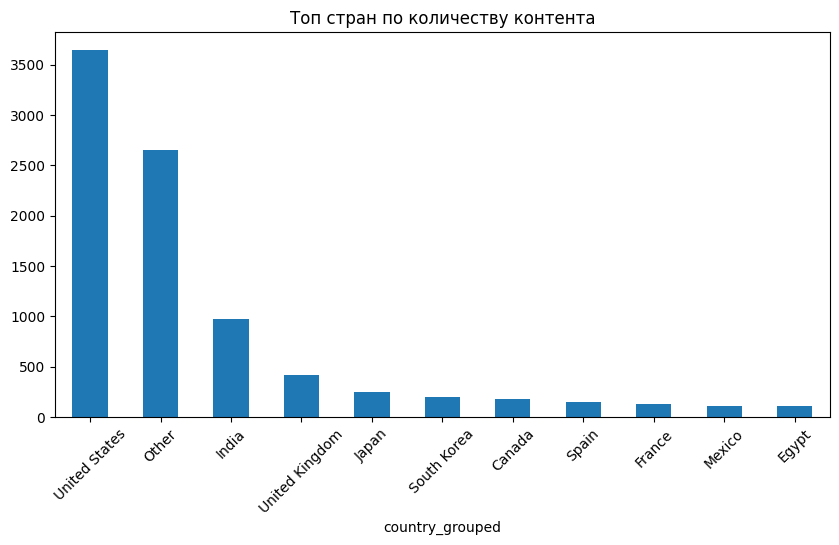

In [35]:
plt.figure(figsize=(10, 5))
# таблица частотности по убыванию + вертикальные столбцы
df['country_grouped'].value_counts().plot(kind='bar')
plt.title('Топ стран по количеству контента')
plt.xticks(rotation=45)
plt.show()

## Heatmap корреляций
Показывает корреляции между числовыми признаками.
- близко к 1 -> сильная положительная связь
- около 0 -> связи нет
- близко к -1 -> отрицательная 

высокая корреляция is_movie и duration_num техническая, т. к. признаки взаимозависимы по логике создания

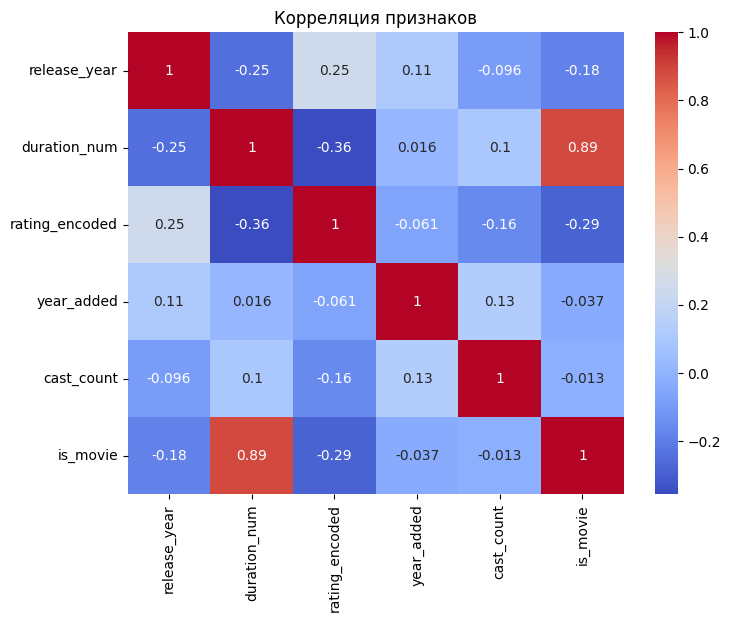

In [36]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['float64', 'int64']) # колонки с числами
# хитмап: коэфф-нт корреляции Пирсона всех пар + показать числа + цвета
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Корреляция признаков')
plt.show()

## Plotly
Интерактивные графики: можно наводить курсор и смотреть детали

In [ ]:
import plotly.express as px
# бд + оси + цвета + титл при наведении
fig = px.scatter(df, x='release_year', y='duration_num', color='type', hover_data=['title'])
fig.show()
# вроде комп не тормозит -_-

## Визуализация: вывод
- Длительность: скошена(histogram) и содержит выбросы(boxplot)
- Большинство значений сосредоточено в определенном диапазоне(histogram, boxplot)
- Явной зависимости между годом выпуска и длительностью не обнаружено(scatterplot)
- Больше фильмов чем сериалов(plotly)
- Несколько стран доминируют по количеству контента(barchart)
- Сильных корреляций между числовыми признаками не выявлено(heatmap)

# F) ИТОГОВЫЕ ВЫВОДЫ И ГИПОТЕЗЫ

## Основные выводы
Датасет содержит информацию о фильмах и сериалах Netflix с различными характеристиками
- В данных присутствовали пропуски
- Большинство признаков являются категориальными
- В датасете больше фильмов, чем сериалов
- Большинство контента было добавлено на платформу в последние годы
- Основная часть контента имеет ограниченный диапазон длительности
- Более длинные фильмы встречаются реже, чем фильмы средней длительности
- Распределение длительности асимметрично и содержит выбросы
- Некоторые страны доминируют по количеству контента
- duration объединяет фильмы и сериалы что немного усложняет анализ

## Гипотезы
- Сериалы чаще добавляются в последние годы по сравнению с фильмами
- Количество актеров может быть связано с популярностью или масштабом проекта
- Новые фильмы имеют тенденцию к меньшей длительности

## Дальнейшие шаги
- Построить модель классификации: предсказать - фильм или сериал
- Построить модель регрессии: предсказание длительности контента
- Проанализировать влияние жанров на длительность и популярность
- Создать рекомендательную систему на основе характеристик контента

## Использование машинного интеллекта
- подсказки по синтаксису pandas
- объяснения метрик

При всем этом все результаты проверялись вручную и выводы формулировались самостоятельно на основе анализа!!

Библиотеки использую впервые так что коммы для себя!!